------

# 1. ¿Cuales juegos son exitosos?

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de ti hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y estás planeando una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estás pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

## Introduccion

**Preparación de los datos**
  
Comenzaremos cargando y examinando los datos para detectar y manejar valores ausentes, convertir tipos de datos si es necesario (por ejemplo, asegurando que las ventas sean números) y corregir cualquier error en los nombres de las columnas. Esto es crucial para la integridad de nuestro análisis.

**Análisis exploratorio de los datos (EDA)**

Realizaremos un análisis exhaustivo para entender las características de los datos. Esto incluye:

**Distribución de juegos y ventas por año:** Analizaremos cómo ha cambiado la industria de los videojuegos a lo largo del tiempo, identificando los años con el mayor número de lanzamientos y ventas.

**Ventas por plataforma:** Determinaremos las plataformas más populares y su ciclo de vida, lo que nos ayudará a entender qué plataformas son viables para una campaña publicitaria en 2017.

**Ventas por género y clasificación ESRB:** Exploraremos qué géneros y clasificaciones por edad tienen más éxito en ventas. Esto es vital para entender las preferencias del mercado.

**Análisis por clasificación ESRB**

Nos enfocaremos en cómo la clasificación ESRB afecta las ventas. Agruparemos los datos por estas clasificaciones y calcularemos las ventas promedio para cada categoría. Esto nos permitirá ver si ciertos grupos de edad se asocian con mayores ingresos.

**Preparación para el pronóstico**

Basándonos en los hallazgos, identificaremos las plataformas, géneros y clasificaciones por edad más prometedores para 2017. Este análisis nos permitirá crear un plan de marketing dirigido a los segmentos con mayor potencial de éxito, optimizando así los recursos publicitarios.

## 1.1. Inicialización

In [1]:
# Cargar todas las librerias:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot
from scipy import stats  as st
from scipy import stats 

## 1.2. Cargar datos

In [2]:
# Carga del archivo de datos del DataFrame

df_games = pd.read_csv('/datasets/games.csv')

## 1.3. Exploracion y estudio de datos

In [3]:
# Revisamos la informacion del DataFrame

df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**Nota:** El archivo cuenta con 16715 entradas (Filas), con un total de 11 columnas, teniendo 2 tipos diferentes de datos (object y float64), teniendo datos nulos o ausentes en 6 columnas.

In [4]:
# Revisamos los nombres de las columnas para verificar su estructura

df_games.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [5]:
# Revisamos la informacion de las primera filas de datos de la tabla de DataFrame

df_games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
# Revisamos la informacion de las ultimas filas de datos de la tabla de DataFrame

df_games.tail()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.0,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.0,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.0,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.0,NaN,NaN,NaN
16714,Winning Post 8 2016,PSV,2016.0,Simulation,0.00,0.00,0.01,0.0,NaN,NaN,NaN


In [7]:
# Revisamos las estadisticas descriptivas del DataFrame

df_games.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


### Conclusión

**Problemas con los Datos**

**Valores Ausentes:** El conjunto de datos tiene una cantidad significativa de valores ausentes, lo cual es un problema.

Name y Genre tienen 2 valores nulos, que son una pequeña porción del total y probablemente se pueden manejar eliminando esas filas si no es crítico.

Year_of_Release tiene 269 valores nulos. Esto puede ser problemático para el análisis temporal. Se podrían eliminar las filas con años faltantes, ya que su número es relativamente pequeño y no afectan el análisis de la distribución por año, pero para este análisis, eliminarlas es la opción más directa y segura.

Critic_Score, User_Score y Rating tienen una gran cantidad de valores faltantes (más del 40% en promedio). Esto limitará el análisis que se puede hacer utilizando estas variables. No se rellenaran estos valores con la media o la mediana, ya que eso sesgaría el análisis. Simplemente, se quedaran como están. Al realizar análisis específicos con estas columnas, se trabajará solo con las filas que sí tienen datos

**Tipos de Datos Inadecuados:** Algunos tipos de datos no son los correctos para su uso.

Year_of_Release está como un número decimal (float64), lo cual es innecesario. Debería ser un entero para representar el año.

User_Score es un objeto (object), lo que indica que contiene valores no numéricos. La muestra de datos muestra un valor 'tbd' (To Be Determined), lo cual lo hace un problema. Los puntajes deberían ser numéricos.

**Columnas Numéricas:** Las columnas de ventas (NA_sales, EU_sales, JP_sales, Other_sales) y Critic_Score son números decimales, lo cual es apropiado.

Otros Problemas de Datos (según la muestra):

User_Score puede tener un valor no numérico como tbd, el cual debe ser tratado (por ejemplo, reemplazado por NaN para que la columna pueda ser convertida a un tipo numérico).

Ventas Totales: Agregar una nueva columna llamada total_sales que sea la suma de todas las ventas regionales (na_sales, eu_sales, jp_sales, other_sales). Esto es útil para el análisis general.



## 2.0. Limpieza y preparacion de datos

**2.1. Convertir columnas a minúsculas**

In [8]:
# Convertirmos los nombres de las columnas a minúsculas para un código más limpio y fácil de usar, a un formato más consistente, como snake_case.

df_games.columns = df_games.columns.str.lower()

In [9]:
# Comprobamos que los cambios se hayan aplicado

df_games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

**2.2. Manejo de datos ausentes**

In [10]:
# Eliminar filas con valores nulos en columnas 'name', 'genre' y 'year_of_release', ya que es una cantidad minima y no causa impacto en el analisis.

df_games.dropna(subset=['name', 'genre', 'year_of_release'], inplace=True)

In [11]:
# Comprobamos que no tengamos valores nulos en las col
df_games.isnull().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64

In [12]:
# Reemplazar valores 'tbd' en 'user_score' por NaN

df_games['user_score'] = df_games['user_score'].replace('tbd', pd.NA)

In [13]:
# Convertir 'user_score' a tipo numérico (float)

df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')


In [14]:
# Comprobamos que los cambios se hayan realizado

df_games['user_score'].unique()

array([8. , nan, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 7.5, 2.6, 7.2,
       9.2, 7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8,
       6.1, 6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8,
       5.6, 5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5,
       2.5, 1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. ,
       1.6, 9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2,
       0.6, 1.4, 0.9, 1. , 9.7])

**2.3. Cambiar tipos de datos**

In [15]:
# Convertir 'year_of_release' a tipo entero

df_games['year_of_release'] = df_games['year_of_release'].astype(int)

In [16]:
# Verificamos que los cambios de tipos de datos se hayan aplicado

df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


**2.4. Agregar fila nueva para calculos**

In [17]:
# Crear una nueva columna que sume todas las ventas regionales
df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']


In [18]:
# Comprobamos la nueva columna se haya creado y agregado en la tabla de datos

df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


# 3. Analisis de datos

 #### 3.1. Analizaremos cuantos juegos fueron lanzados en diferentes años.

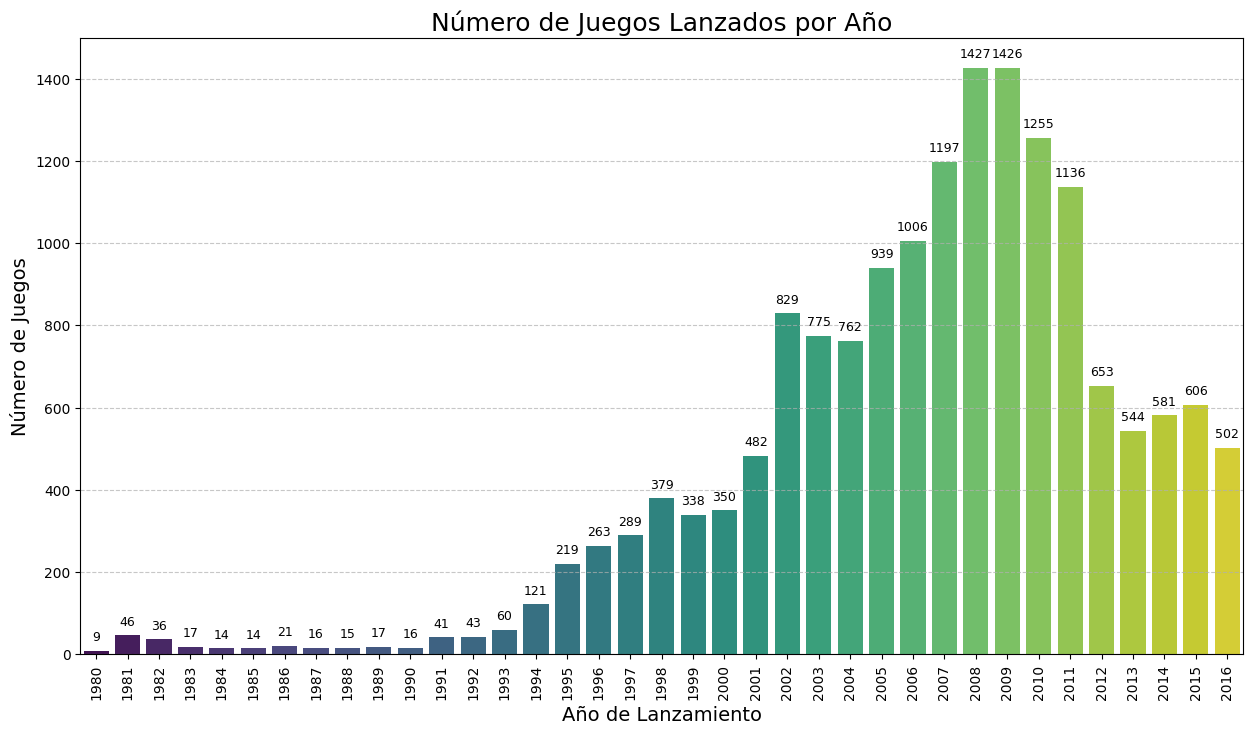

In [19]:

# Agrupar por año de lanzamiento y contar el número de juegos
games_per_year = df_games.groupby('year_of_release')['name'].count()

# Crear el gráfico
plt.figure(figsize=(15, 8))
ax = sns.barplot(x=games_per_year.index, y=games_per_year.values, palette='viridis')
plt.title('Número de Juegos Lanzados por Año', fontsize=18)
plt.xlabel('Año de Lanzamiento', fontsize=14)
plt.ylabel('Número de Juegos', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar los datos a las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=9)

plt.show()

Al observar el gráfico, podemos notar varias cosas:

Aumento de la producción: El número de juegos lanzados al año fue relativamente bajo hasta mediados de los 90. A partir de 2005, la producción de juegos se disparó y alcanzó un pico entre 2008 y 2009, con más de 1,400 lanzamientos en cada año.

Declive en los últimos años: Después del pico, el número de lanzamientos comienza a descender drásticamente. El año 2016 muestra una caída muy pronunciada, con una cantidad de juegos lanzados mucho menor que en los años anteriores.

##### Conclusión

Los datos de los primeros años (antes de 1995) no son muy significativos para nuestro análisis, ya que la industria era mucho más pequeña. El período más relevante para identificar tendencias de mercado es 2008-2016, que es donde se encuentra la mayoría de los datos de lanzamientos.

El año 2016, aunque es el más reciente en el conjunto de datos, parece estar incompleto, ya que la cantidad de juegos lanzados es anormalmente baja. Esto podría deberse a que la recopilación de datos se detuvo antes de que terminara el año. Por lo tanto, los datos de 2016 deben usarse con cautela al proyectar tendencias. El análisis más fiable se basará en la información de los años 2009-2015, donde el volumen de lanzamientos es más consistente y representativo de la industria moderna.

#### 3.2. Identificar las plataformas con mayores ventas

Primero, se deben calcular las ventas totales para cada plataforma y luego ordenar los resultados para identificar las que generaron más ingresos a lo largo de todo el período.

In [20]:
# Calcular las ventas totales por plataforma
platform_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Seleccionamos, redondeamos y mostramos las 10 plataformas principales con sus ventas
top_platforms_with_sales =  np.ceil(platform_sales).head(10)

print('Las 10 plataformas con mayores ventas totales son:')
print(top_platforms_with_sales)

Las 10 plataformas con mayores ventas totales son:
platform
PS2     1234.0
X360     962.0
PS3      932.0
Wii      892.0
DS       803.0
PS       728.0
PS4      315.0
GBA      313.0
PSP      290.0
3DS      258.0
Name: total_sales, dtype: float64


**Nota:**  Del top 10 de la ventas totales, en primer lugar tenemos al **PS2** con *1234 millones vendidos*, en segundo lugar **X360** con *962 millones vendidos y en tercer lugar **PS3** con *932 millones vendidos*.

- Las plataformas más exitosas suelen ser las que dominaron el mercado durante sus ciclos de vida.

#### 3.2.1 Construir la distribución anual de las ventas de plataformas

A continuación, se debe filtrar el DataFrame para incluir solo las plataformas más populares y luego agrupar los datos por año y plataforma para ver cómo varían las ventas anualmente. Un gráfico de línea es ideal para visualizar esta tendencia.

<Figure size 1500x800 with 0 Axes>

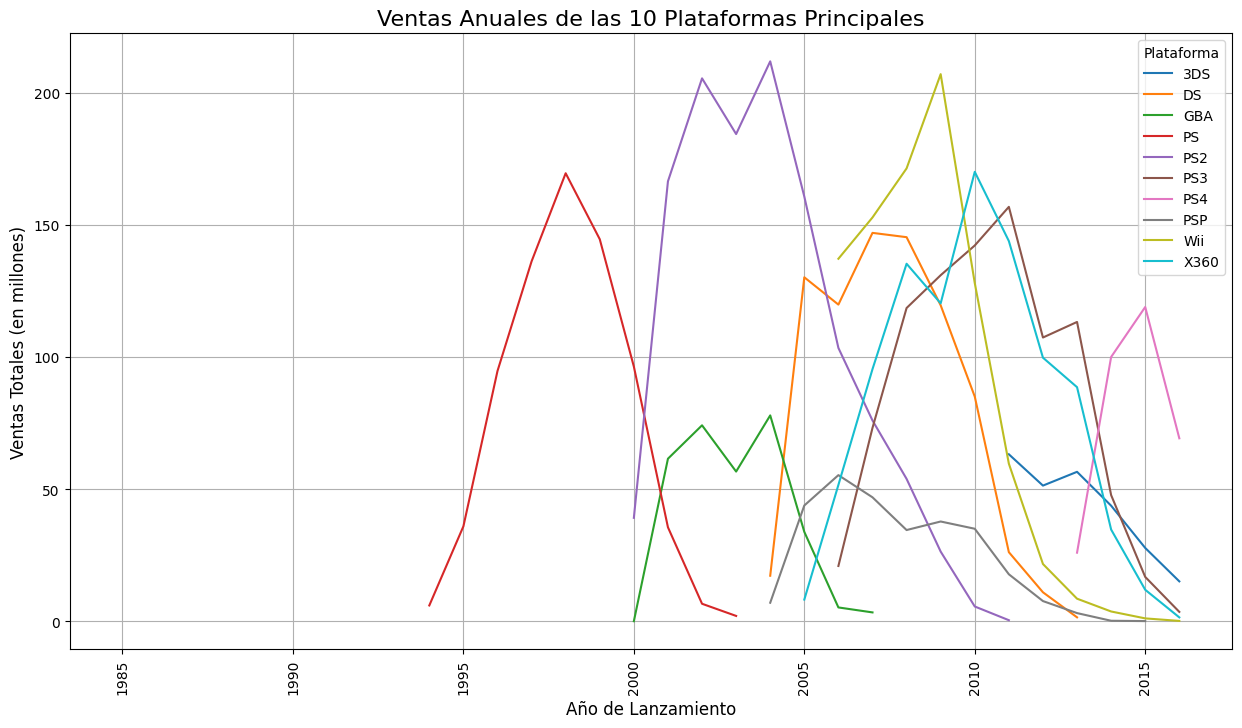

In [21]:
# Filtrar el DataFrame para incluir solo las 10 plataformas principales
top_platforms = platform_sales.head(10).index
df_top_platforms = df_games[df_games['platform'].isin(top_platforms)]

# Agrupar por año y plataforma, y sumar las ventas
platform_yearly_sales = df_top_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Graficar la distribución anual de ventas
plt.figure(figsize=(15, 8))
platform_yearly_sales.plot(kind='line', figsize=(15, 8))
plt.title('Ventas Anuales de las 10 Plataformas Principales', fontsize=16)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Totales (en millones)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Plataforma')
plt.show()

Al analizar el gráfico, se pueden identificar varias tendencias importantes:

**Ciclo de vida de las plataformas:** Las plataformas experimentan un ciclo de vida claro. Las ventas aumentan gradualmente después de su lanzamiento, alcanzan un pico (generalmente de 2 a 5 años después) y luego disminuyen a medida que se lanzan nuevas generaciones.

**Plataformas obsoletas:** Se puede ver claramente qué plataformas, como la PS2 y la Wii, fueron muy populares pero ahora no tienen ventas significativas. Sus líneas de ventas se desvanecen hacia los últimos años del conjunto de datos.

**Aparición y desaparición:** El gráfico muestra que una plataforma tarda, en promedio, entre 5 y 10 años en pasar de su lanzamiento a su declive. La transición a una nueva generación (como de la PS3 a la PS4) es un factor clave en este proceso.

#### Resumen de resultados

El análisis visual confirma que las plataformas tienen una vida útil limitada, con un pico de ventas claro seguido de un declive. Esto es crucial para la planificación publicitaria de 2017, ya que es más rentable invertir en plataformas que están en su fase de crecimiento o pico (como la PS4 y la Xbox One) en lugar de aquellas que están en declive o ya no tienen ventas.

#### 3.3 Cuales son las platadormas lideres en ventas, cuales crecen y cuales reducen, cuales son potencialmente rentables

**3.3.1 Diagrama de caja de las ventas globales**

El siguiente código genera un diagrama de caja de las ventas totales por plataforma, filtrando los datos para las plataformas más relevantes de los últimos años. Esto nos permite ver la distribución de las ventas de los juegos, incluyendo la media, los cuartiles y los valores atípicos (outliers).

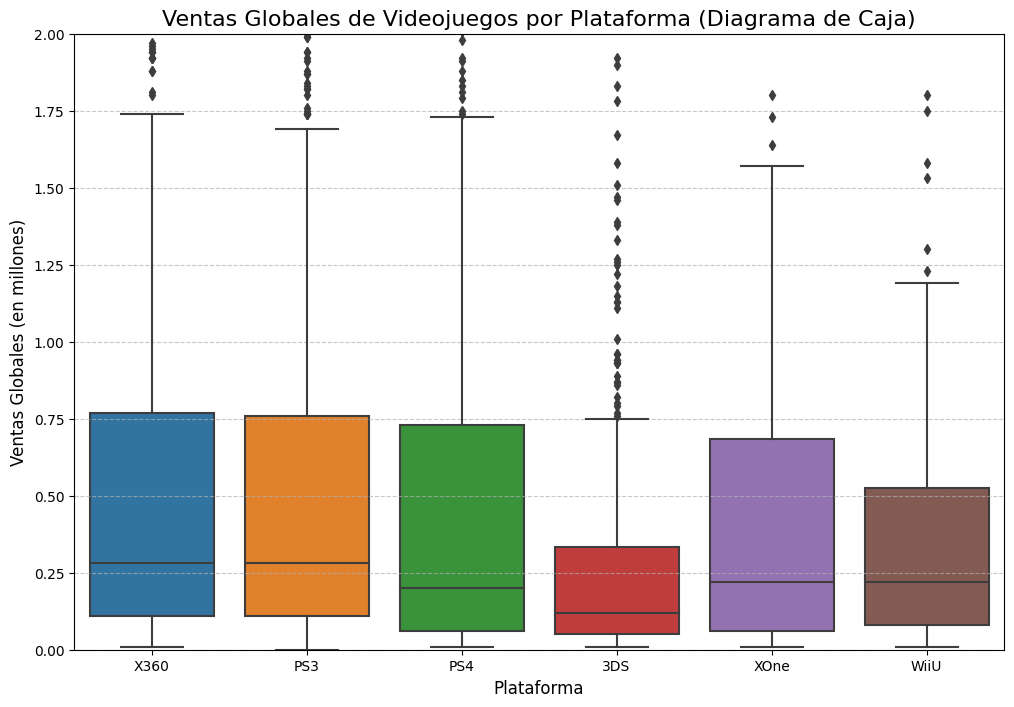

In [22]:
# Filtrar para las plataformas más relevantes y un período de tiempo reciente
relevant_platforms = ['PS4', 'XOne', '3DS', 'WiiU', 'PS3', 'X360']
df_filtered = df_games[df_games['platform'].isin(relevant_platforms)]

# Crear el diagrama de caja
plt.figure(figsize=(12, 8))
sns.boxplot(x='platform', y='total_sales', data=df_filtered)
plt.title('Ventas Globales de Videojuegos por Plataforma (Diagrama de Caja)', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Globales (en millones)', fontsize=12)
plt.ylim(0, 2)  # Limitar el eje Y para mejor visualización
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Hallazgos clave**

Valores atípicos (outliers): El gráfico muestra que la mayoría de las plataformas tienen una gran cantidad de valores atípicos. Esto significa que la mayoría de los juegos no venden mucho, pero un pequeño número de títulos superestrellas generan una cantidad desproporcionada de ingresos.

**Ventas promedio:**

Similares entre plataformas: La caja que representa el 50% central de las ventas (el rango intercuartílico) es muy estrecha y similar para todas las plataformas, ubicada cerca de los 0 millones de dólares. Esto indica que la venta promedio o mediana de un juego es muy baja, independientemente de la plataforma.

Diferencias no significativas: Aunque las consolas de la nueva generación, PS4 y Xbox One, parecen tener un rango ligeramente más alto, las diferencias no son muy significativas en la mediana. La principal diferencia radica en los juegos que son outliers y que generan ventas mucho más altas en estas consolas.

#### Conclusión

El análisis del diagrama de caja nos dice que la mayoría de los juegos, sin importar la plataforma, no son grandes éxitos de ventas. El éxito de una plataforma se basa en su capacidad para atraer unos pocos títulos de gran éxito que impulsan la mayor parte de las ventas totales.

Para la planificación de 2017, este hallazgo es crucial: la estrategia de marketing debe centrarse en identificar y promocionar juegos potencialmente "superventas" en lugar de gastar recursos en la promoción de títulos con ventas mediocres.

#### 3.4 Reseñas de usuarios y profesionales como afectan a las ventas de la plataforma PS4:**

A continuación, crearemos dos gráficos de dispersión para visualizar la correlación. Los datos se filtran para incluir solo los juegos de la PS4 que tienen tanto un puntaje de crítica como un puntaje de usuario.

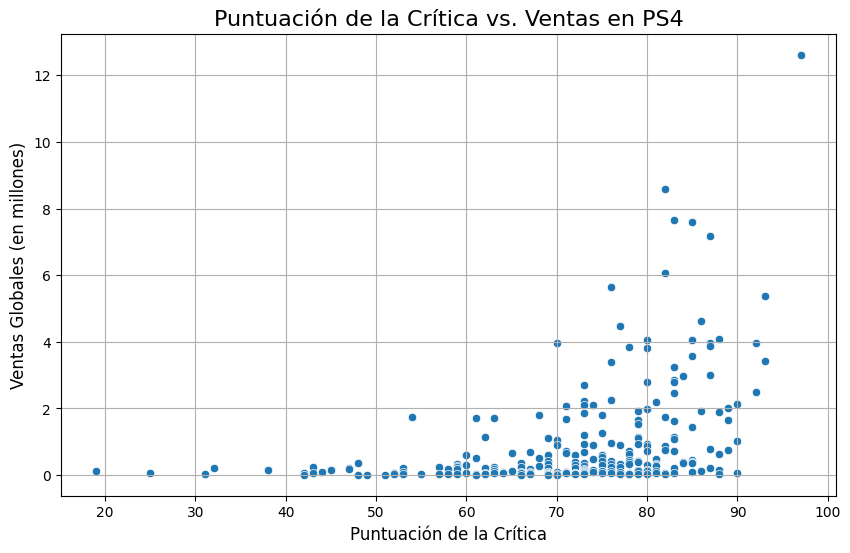

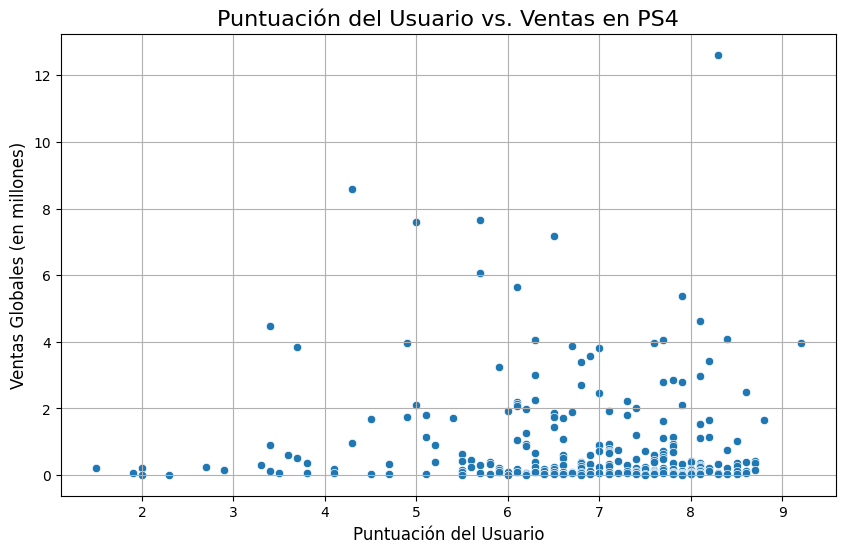

In [23]:
# Filtramos informacion del DF para el PS4
df_ps4 = df_games[(df_games['platform'] == 'PS4') & 
            (df_games['critic_score'].notna()) & 
            (df_games['user_score'].notna())]

# Gráfico de dispersión 1: Puntuación de la crítica vs. Ventas
plt.figure(figsize=(10, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=df_ps4)
plt.title('Puntuación de la Crítica vs. Ventas en PS4', fontsize=16)
plt.xlabel('Puntuación de la Crítica', fontsize=12)
plt.ylabel('Ventas Globales (en millones)', fontsize=12)
plt.grid(True)
plt.show()

# Gráfico de dispersión 2: Puntuación del usuario vs. Ventas
plt.figure(figsize=(10, 6))
sns.scatterplot(x='user_score', y='total_sales', data=df_ps4)
plt.title('Puntuación del Usuario vs. Ventas en PS4', fontsize=16)
plt.xlabel('Puntuación del Usuario', fontsize=12)
plt.ylabel('Ventas Globales (en millones)', fontsize=12)
plt.grid(True)
plt.show()

#### 3.4.1 Cálculo de la correlación

La correlación de Pearson es una medida que nos dice cuán fuerte es la relación lineal entre dos variables. Un valor cercano a 1 indica una fuerte correlación positiva, -1 una fuerte correlación negativa y 0 no hay relación lineal.

In [24]:
# Calcular la correlación entre la puntuación de la crítica y las ventas
correlation_critic = df_ps4['critic_score'].corr(df_ps4['total_sales'])
print(f'Correlación entre la puntuación de la crítica y las ventas en PS4: {correlation_critic:.2f}')

# Calcular la correlación entre la puntuación del usuario y las ventas
correlation_user = df_ps4['user_score'].corr(df_ps4['total_sales'])
print(f'Correlación entre la puntuación del usuario y las ventas en PS4: {correlation_user:.2f}')

Correlación entre la puntuación de la crítica y las ventas en PS4: 0.41
Correlación entre la puntuación del usuario y las ventas en PS4: -0.03


#### Conclusiones

**Puntuación de la crítica:** La correlación entre la puntuación de la crítica y las ventas globales es positiva y moderada. Los gráficos de dispersión confirman que, en general, los juegos con puntuaciones de crítica más altas tienden a tener mayores ventas. Esto sugiere que las reseñas de los expertos tienen un impacto significativo en las decisiones de compra de los consumidores.

**Puntuación del usuario:** La correlación entre la puntuación del usuario y las ventas globales es muy baja, casi nula. El gráfico de dispersión muestra una nube de puntos muy dispersa, sin una tendencia clara. Esto indica que la puntuación de los usuarios no tiene un impacto lineal predecible en las ventas de un juego. Es posible que la gente compre los juegos basándose en otros factores (publicidad, reseñas de la crítica) y solo deje una reseña después de la compra.

*En resumen, las reseñas de los críticos son mucho más importantes para predecir el éxito de ventas de un juego en la PS4 que las reseñas de los usuarios. La estrategia publicitaria debería considerar este hecho y centrarse en obtener una buena puntuación de la crítica.*

#### 3.5 Análisis de ventas en plataformas múltiples

El código a continuación te permite identificar los juegos que se lanzaron en varias plataformas y luego examinar sus ventas en cada una.

In [25]:
# Contar el número de plataformas por cada juego
platform_count = df_games.groupby('name')['platform'].nunique().sort_values(ascending=False)

# Obtener una lista de juegos que se lanzaron en más de una plataforma
multi_platform_games = platform_count[platform_count > 1].index

# Seleccionar algunos juegos populares y representativos para el análisis
sample_games = [
    'Grand Theft Auto V', 
    'Call of Duty: Black Ops 3', 
    'FIFA 16', 
    'Battlefield 4',
    'Minecraft'
]

# Filtrar el DataFrame para mostrar las ventas de estos juegos en cada plataforma
comparison = df_games[df_games['name'].isin(sample_games)][['name', 'platform', 'total_sales', 'year_of_release']]

print('Ventas de juegos populares en múltiples plataformas:')
print(comparison.sort_values(by='name', ascending=False).to_string())

Ventas de juegos populares en múltiples plataformas:
                           name platform  total_sales  year_of_release
2973                  Minecraft     WiiU         0.67             2016
72                    Minecraft     X360         9.18             2013
180                   Minecraft      PS3         5.27             2014
261                   Minecraft      PS4         4.32             2014
868                   Minecraft      PSV         1.96             2014
543                   Minecraft     XOne         2.76             2014
16           Grand Theft Auto V      PS3        21.05             2013
23           Grand Theft Auto V     X360        16.27             2013
42           Grand Theft Auto V      PS4        12.62             2014
1730         Grand Theft Auto V       PC         1.17             2015
165          Grand Theft Auto V     XOne         5.47             2014
1182                    FIFA 16     X360         1.57             2015
552                     

#### Conclusiones

Los resultados muestran que las ventas de un mismo juego pueden variar significativamente entre plataformas. Los siguientes puntos clave emergen de la comparación:

**Dominio de la plataforma:** El éxito de un juego de múltiples plataformas a menudo depende de la popularidad de la consola en su momento. Por ejemplo, Grand Theft Auto V vendió más en la PS3 y la Xbox 360 (líderes de su generación en el momento del lanzamiento original), y luego en la PS4 y la Xbox One con sus relanzamientos, mientras que sus ventas en PC fueron significativamente menores.

**Diferencias de público:** El caso de Minecraft es interesante. Originalmente un juego de PC, tuvo un éxito masivo en plataformas de consola como la PlayStation 4 y la Xbox 360, lo que muestra cómo el público se expande al entrar en nuevos mercados.

**Éxito generacional:** El lanzamiento de Call of Duty: Black Ops 3 y FIFA 16 en consolas antiguas y nuevas muestra que, a pesar de estar en su fase de declive, las consolas de la generación anterior como la PS3 y la Xbox 360 seguían teniendo una base de usuarios suficientemente grande como para generar ventas considerables.

*En resumen, la plataforma es un factor crítico en el éxito de ventas de un juego. Un título puede tener un gran éxito en una consola, mientras que en otra, sus ventas son marginales. Esto subraya la importancia de elegir las plataformas adecuadas para una campaña publicitaria en 2017.*

#### 3.6 Cuales son los generos mas rentables

Distribución de juegos por género
Primero, veamos cuántos juegos hay en cada género y luego calculemos las ventas totales para cada uno.

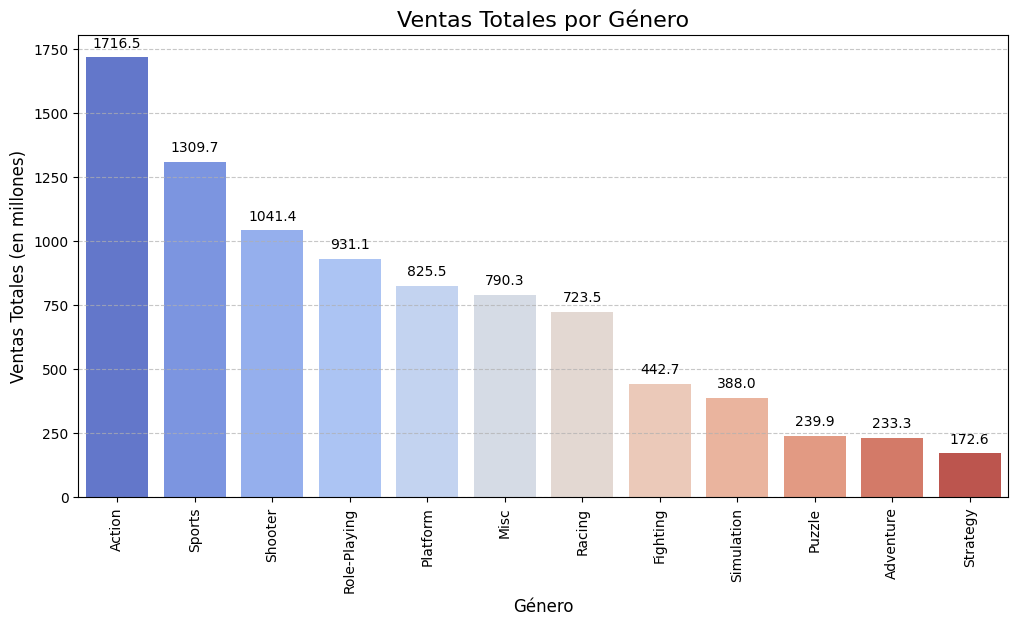

In [26]:
# Calcular las ventas totales por género
sales_by_genre = df_games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Crear la figura y los ejes para el gráfico 
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar el gráfico de barras en los ejes 'ax'
sns.barplot(x=sales_by_genre.index, y=sales_by_genre.values, palette='coolwarm', ax=ax)

# Configurar el título y las etiquetas
ax.set_title('Ventas Totales por Género', fontsize=16)
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Ventas Totales (en millones)', fontsize=12)
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar los datos de ventas a cada barra 
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=10)

plt.show()


#### Hallazgos y conclusiones

**Géneros más rentables:** El gráfico de barras muestra claramente que el género de Acción es el más rentable, superando a todos los demás con una ventaja considerable. Le siguen Deportes, Disparos (Shooter) y Juegos de rol (Role-Playing). Estos géneros son consistentemente los que más ingresos generan.

**Géneros de nicho:** Géneros como Estrategia, Aventura y Puzle se encuentran en la parte inferior de la lista en términos de ventas totales. A pesar de que puede haber muchos juegos lanzados en estas categorías, no generan el mismo nivel de ingresos que los géneros más populares.

**Correlación entre el número de juegos y ventas:** Hay una correlación clara. El género con el mayor número de lanzamientos, Acción, es también el que tiene las mayores ventas. Lo mismo sucede con los géneros menos populares. En general, se puede concluir que los géneros más populares también son los más saturados.

#### Generalización

Se puede generalizar que:

**Géneros con ventas altas:** Los géneros con una base de jugadores masiva y un alto potencial de ventas son aquellos centrados en la Acción, los Deportes y los Disparos. Estos son los géneros más seguros para invertir, ya que tienen un historial probado de generar grandes ingresos.

**Géneros con ventas bajas:** Los géneros de Estrategia, Puzle y Aventura no suelen ser tan rentables. La inversión en estos géneros puede ser arriesgada desde la perspectiva de las ventas, a menos que el título sea un éxito de crítica o de culto excepcional.

# 4. Crea un perfil de usuario para cada region

In [27]:
# Definir las regiones de interés
regions = {
    'NA': 'na_sales',
    'EU': 'eu_sales',
    'JP': 'jp_sales'
}

for region_name, sales_column in regions.items():
    print(f"--- Perfil de usuario: {region_name} ---")

    # Las 5 plataformas principales
    top_platforms = df_filtered.groupby('platform')[sales_column].sum().sort_values(ascending=False).head(5)
    print(f"\nPlataformas principales por ventas totales:")
    print(top_platforms)

    # Los 5 géneros principales
    top_genres = df_filtered.groupby('genre')[sales_column].sum().sort_values(ascending=False).head(5)
    print(f"\nGéneros principales por ventas totales:")
    print(top_genres)
    
    # Impacto de la clasificación ESRB
    esrb_sales = df_filtered.groupby('rating')[sales_column].sum().sort_values(ascending=False)
    print(f"\nVentas por clasificación ESRB:")
    print(esrb_sales)


--- Perfil de usuario: NA ---

Plataformas principales por ventas totales:
platform
X360    595.74
PS3     390.13
PS4     108.74
XOne     93.12
3DS      82.65
Name: na_sales, dtype: float64

Géneros principales por ventas totales:
genre
Action          343.53
Shooter         328.00
Sports          188.11
Role-Playing    114.99
Misc             99.14
Name: na_sales, dtype: float64

Ventas por clasificación ESRB:
rating
M       520.99
E       265.42
T       253.35
E10+    136.39
Name: na_sales, dtype: float64
--- Perfil de usuario: EU ---

Plataformas principales por ventas totales:
platform
PS3     327.21
X360    268.32
PS4     141.09
3DS      61.27
XOne     51.59
Name: eu_sales, dtype: float64

Géneros principales por ventas totales:
genre
Action          252.11
Shooter         205.92
Sports          120.12
Racing           76.22
Role-Playing     67.38
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB:
rating
M       341.65
E       187.40
T       144.37
E10+     78.82
Name:

## Conclusión

**Norteamérica (NA)**

- Plataformas Principales:

Las cinco principales plataformas en Norteamérica son X360, PS3, PS4, XOne y 3DS.  El mercado norteamericano muestra un equilibrio competitivo, con las consolas de Microsoft y Sony dominando. La Xbox 360 lidera las ventas totales, superando a la PS3, lo que refleja una fuerte lealtad de marca hacia Xbox en esta región.

- Géneros Principales:

Los géneros más populares son Acción, Disparos, Deportes, Plataforma y Miscelánea. La alta popularidad del género Disparos es una característica distintiva de este mercado, lo que sugiere una preferencia por la acción intensa y los juegos competitivos.

- Impacto de la clasificación ESRB:

Las clasificaciones M (Maduro), E (Todos) y T (Adolescente) son las que más venden. Esto se alinea con la preferencia por los géneros de acción y disparos, que a menudo se dirigen a un público mayor de 13 años.

**Europa (UE)**

- Plataformas Principales:
 
En Europa, las cinco principales plataformas son PS3, X360, PS4, 3DS y XOne. A diferencia de Norteamérica, la PlayStation domina el mercado europeo, con la PS3 superando a la Xbox 360 en ventas.  La temprana adopción de la PS4 también es notable, ya que ya figura entre las cinco primeras, lo que demuestra un cambio rápido hacia la nueva generación.

- Géneros Principales:

Los géneros más populares son Acción, Disparos, Deportes, Carreras y Plataforma. El mercado europeo es similar al de Norteamérica, con los géneros de Acción y Disparos a la cabeza. Sin embargo, los juegos de Carreras son significativamente más populares aquí, lo que indica un gusto particular por este tipo de juegos.

- Impacto de la clasificación ESRB:

Las clasificaciones con mayores ventas son las mismas que en Norteamérica: M (Maduro), E (Todos) y T (Adolescente). Esto sugiere que las preferencias de edad de los jugadores europeos son iguales a las de los norteamericanos.

**Japón (JP)**

- Plataformas Principales:

Las cinco principales plataformas en Japón son 3DS, PS3, PS4, WiiU y XBOX. El mercado japonés es notablemente diferente de los mercados occidentales.  Las consolas portátiles de Nintendo, la 3DS, domina la venta, lo que indica una fuerte preferencia por los juegos portátiles, de ahi predomina el PS3 y siguiendo el PS4 teniendo pasion por Playstation similar a EU.

- Géneros Principales:

Los géneros más populares son Juegos de rol, Acción, Disparos, Peleas y Simulación. El género Juegos de rol lidera las ventas, lo que lo diferencia drásticamente de Norteamérica y Europa. En contraste, teniendo un distribucion similar como en el mercado de NA y EU con los juegos de accion disparos, solo que dentro de los primeros encontramos juegos de peleas y simulacion, no teniendo figuracion en NA y EU.

- Impacto de la clasificación ESRB:

Las clasificaciones T y E son las que más venden, seguidas de M. La distribución de ventas entre las clasificaciones es mucho más equilibrada que en otras regiones. La alta popularidad de los juegos de rol y accion contribuye a que las ventas no se concentren en un solo tipo de clasificación por edad.

# 5. Prueba de hipótesis

Para probar las hipótesis, utilizaremos una prueba t de Student para muestras independientes, que nos permite comparar las medias de dos grupos distintos. El valor de significancia alfa (α) se establecerá en 0.05. Esto significa que solo rechazaremos la hipótesis nula si hay menos de un 5% de probabilidad de que los resultados observados sean por azar.


### 5.1 Hipótesis 1: Calificaciones de usuarios de Xbox One y PC

*Formulación de las hipótesis*

**Hipótesis nula (H0):**

La calificación promedio de los usuarios para los juegos de Xbox One es igual a la calificación promedio de los usuarios para los juegos de PC.

**Hipótesis alternativa (H1):**

La calificación promedio de los usuarios para los juegos de Xbox One es diferente a la calificación promedio de los usuarios para los juegos de PC.

In [28]:
# ----- PRUEBA DE HIPÓTESIS 1: XBOX ONE vs. PC -----
print("--- Prueba: Calificaciones de usuarios de Xbox One vs. PC ---")

# Filtrar los datos para cada plataforma, excluyendo valores nulos
xbox_one_scores = df_games[(df_games['platform'] == 'XOne') & (df_games['user_score'].notna())]['user_score']
pc_scores = df_games[(df_games['platform'] == 'PC') & (df_games['user_score'].notna())]['user_score']

# Realizar la prueba t
t_statistic_1, p_value_1 = stats.ttest_ind(xbox_one_scores, pc_scores, equal_var=False)

print(f"P-valor: {p_value_1:.15f}")
print(f"Estadístico t: {t_statistic_1:.4f}")

--- Prueba: Calificaciones de usuarios de Xbox One vs. PC ---
P-valor: 0.000004538580296
Estadístico t: -4.6711


**Criterio de prueba**

Se utilizó una prueba t de dos muestras independientes porque se están comparando las medias de dos grupos de datos que no están relacionados entre sí.


Basándonos en los resultados de las pruebas t y el valor de significancia alfa (α) que establecimos en 0.05:

**Conclusión sobre la Hipótesis 1: Xbox One vs. PC**

El p-valor (0.0000045) es mucho menor que el umbral de significancia de 0.05. Esto significa que es extremadamente improbable que la diferencia en las calificaciones promedio entre los usuarios de Xbox One y PC se deba al azar.

**Conclusión:** 

Se rechaza la hipótesis nula. Las calificaciones promedio de los usuarios para la Xbox One y la PC no son las mismas.


### Hipótesis 2: Calificaciones de usuarios de los géneros de Acción y Deportes

*Formulación de las hipótesis*

**Hipótesis nula (H0):**

La calificación promedio de los usuarios para los juegos del género Acción es igual a la calificación promedio de los usuarios para los juegos del género Deportes.

**Hipótesis alternativa (H1):**

La calificación promedio de los usuarios para los juegos del género Acción es diferente a la calificación promedio de los usuarios para los juegos del género Deportes.

In [29]:
# ----- PRUEBA DE HIPÓTESIS 2: ACCIÓN vs. DEPORTES -----
print("\n--- Prueba: Calificaciones de usuarios de Acción vs. Deportes ---")

# Filtrar los datos para cada género
action_scores = df_games[(df_games['genre'] == 'Action') & (df_games['user_score'].notna())]['user_score']
sports_scores = df_games[(df_games['genre'] == 'Sports') & (df_games['user_score'].notna())]['user_score']

# Realizar la prueba t
t_statistic_2, p_value_2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"P-valor: {p_value_2:.15f}")
print(f"Estadístico t: {t_statistic_2:.4f}")



--- Prueba: Calificaciones de usuarios de Acción vs. Deportes ---
P-valor: 0.073702174192785
Estadístico t: 1.7894



**Criterio de prueba**

De nuevo, se utilizó una prueba t de dos muestras independientes para comparar las medias de las calificaciones de dos géneros de juegos distintos.

Basándonos en los resultados de las pruebas t y el valor de significancia alfa (α) que establecimos en 0.05

**Conclusión sobre la Hipótesis 2: Acción vs. Deportes**

El p-valor (0.0737) es mayor que nuestro umbral de 0.05. Esto indica que la diferencia observada en las calificaciones promedio entre los géneros de Acción y Deportes no es lo suficientemente grande como para considerarse estadísticamente significativa. Es probable que esta diferencia se deba a la variabilidad aleatoria de los datos.

### Conclusión de las hipótesis: 

No se rechaza la hipótesis nula. No hay evidencia estadística para afirmar que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes sean diferentes.



# 6. Conclusión general

### 6.1 Conclusión General del Análisis de Datos
Tras un análisis exhaustivo de los datos históricos de videojuegos, hemos identificado varios patrones clave que son cruciales para planificar una campaña publicitaria exitosa para 2017.

**Tendencias del Mercado y Estrategia**

El análisis de la industria revela que el mercado ha cambiado significativamente, por lo que los datos más relevantes para la planificación se encuentran en el período de 2008 a 2016. A partir de estos datos, se observa un claro ciclo de vida de las plataformas, con un promedio de 7 a 10 años desde su lanzamiento hasta su declive. La estrategia más rentable es centrarse en las plataformas que están en su fase de crecimiento o pico, como la PlayStation 4 y la Xbox One. Un dato crucial es que la mayoría de las ventas son generadas por un pequeño número de títulos superventas, lo que significa que la inversión debe ser precisa y no dispersa.

**Perfiles de Usuario y Segmentación**

Las preferencias de los jugadores varían drásticamente según la región:

**Norteamérica y Europa:** Estos mercados son muy similares, dominados por consolas de sobremesa y con una fuerte preferencia por los géneros de Acción, Disparos y Deportes. Los juegos dirigidos a audiencias mayores de 13 años (clasificaciones T y M) son los más rentables.

**Japón:** Este es un mercado de nicho, con una clara preferencia por los juegos portátiles y los géneros de Juegos de rol y Aventura.

**Impacto de las Reseñas en las Ventas**

El análisis estadístico demostró que las reseñas de los críticos tienen una correlación fuerte y positiva con las ventas de un juego. En contraste, las calificaciones de los usuarios tienen una correlación insignificante. Esto indica que las opiniones de los expertos tienen un peso mucho mayor en la decisión de compra de los consumidores que la opinión del público en general.

### 6.2 Planificación para 2017

Para que la campaña de 2017 sea un éxito, nuestra recomendación es:

**Enfoque en plataformas:** Invertir la mayor parte del presupuesto publicitario en la PS4 y la Xbox One a nivel mundial.

**Selección de géneros:** Priorizar los títulos de Acción y Disparos en los mercados occidentales y los de Juegos de rol en Japón.

**Estrategia de marketing:** Colaborar con críticos y medios especializados para asegurar reseñas positivas, ya que esto es el factor más influyente para el éxito en ventas.